# Kartläggning av mobiltäckning med en vägdämpningskonturyta

## Sammanfattning

Ett RF-planeringsteam på ett telekombolag renderar nedlänkens **vägdämpningsyta** kring en enskild makrocell som en tvådimensionell täckningskarta. Med en logaritmisk avståndsmodell för utbredning och log-normal skuggfädning bygger den här notebooken ett mätrutnät med 100 punkter (10 x 10 rutor över ett 10 km x 10 km serviceområde, mast i centrum) och ritar en fylld konturyta med **PROC SGPLOT HEATMAPPARM** samt en gradientfärgskala och referenslinjer för masten.

På det körda rutnätet varierar vägdämpningen från **50,4 dB** (i den ljusa bassängen vid masten) till **90,0 dB** i det bortre hörnet, med ett genomsnitt på **75,6 dB**. Klassificering av varje ruta efter dess dämpning ger **38 Stark, 61 Godkänd och 1 Svag** ruta; den ensamma Svag-rutan ligger vid **(9,5, 9,5) km — hörnet diagonalt motsatt masten — vid 89,97 dB**, det enda täckningshål en planerare skulle flagga inför ett beslut om small-cell-komplettering.

> **En anmärkning om proceduren.** I SAS är det klassiska verktyget för konturkartor med isolinjer `PROC GCONTOUR`. Jenner parsar GCONTOUR och genererar en korrekt plot-specifikation, men dess rasterrenderare ritar ännu inte konturgeometrin (bilden kommer tillbaka tom); den bristen är bankad som regressionstestet `tests/400922_nb_gcontour_empty_render`. För att hålla det här exemplet fullt förankrat i en verkligt renderad figur använder vi den SAS-kompatibla motsvarigheten — `PROC SGPLOT` med en `HEATMAPPARM`-sats — som renderar samma rutnätsbaserade (x, y, z)-yta som fyllda konturrutor med en gradientförklaring.

## Datakällor

**Syntetiskt dataset: `pathloss_grid`** (100 rader — ett 10 x 10-rutnät)

| Variabel | Typ | Enhet | Beskrivning |
|----------|------|-------|-------------|
| `east_km` | num | km | Östkoordinat för rutans mittpunkt (0,5 till 9,5); x-axel |
| `north_km` | num | km | Nordkoordinat för rutans mittpunkt (0,5 till 9,5); y-axel |
| `path_loss` | num | dB | Nedlänkens vägdämpning = 58 + 30 log10(avstånd) + skugga; responsvariabeln (z) |
| `zone` | char(8) | — | Täckningsklass: Stark (<=75), Godkänd (<=88), Svag (>88) |

Masten står i rutnätets centrum **(5, 5) km**. Vägdämpningen ökar med 10-logaritmen av avståndet från masten; en `3*rand("normal")`-skuggterm (frö 80211) injicerar log-normal fädning så att konturerna inte blir perfekt cirkulära. 10 x 10-rutnätet är dimensionerat så att hela ytan ryms inom 100 observationer.

## Steg 1 — Generera mätrutnätet

Vi lägger ut ett rutnät med 1 km mellanrum mellan rutcentra och beräknar vägdämpningen med den **logaritmiska avståndsmodellen** `PL = 58 + 30 log10(d)`, där `d` är avståndet från masten vid (5, 5) km. En `rand("normal")`-skuggfädningsterm återger den variation som ses i verkliga drivetester. Varje ruta klassificeras i en täcknings-`zone`. `call streaminit` fixerar slumptalsfröet för reproducerbarhet.

In [1]:
data pathloss_grid;
   CALL streaminit(80211);
   LÄNGD zone $10;
   tower_x = 5.0;  tower_y = 5.0;
   GÖR ix = 1 TILL 10;
      GÖR iy = 1 TILL 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         dist = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(dist) + shadow;
         OM      path_loss <= 75 SÅ zone = "Stark";
         ANNARS OM path_loss <= 88 SÅ zone = "Godkänd";
         ANNARS                         zone = "Svag";
         UTDATA;
      SLUT;
   SLUT;
   TA_BORT ix iy tower_x tower_y dist shadow;
   ETIKETT east_km   = "Öst (km)"
         north_km  = "Nord (km)"
         path_loss = "Vägdämpning (dB)"
         zone      = "Täckningsklass";
KÖR;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Steg 2 — Sammanfatta ytan

Innan vi plottar kvantifierar vi ytan. `PROC MEANS` rapporterar variationsbredden för vägdämpningen och `PROC FREQ` tabellerar hur de 100 rutorna fördelar sig på de tre täckningsklasserna — siffrorna som sammanfattningen ovan citerar.

In [2]:
ODS GRAPHICS OFF;

PROCEDUR MEDELVÄRDEN data=pathloss_grid min max mean maxdec=1;
   VARIABEL path_loss;
   ETIKETT path_loss = "Vägdämpning (dB)";
KÖR;

PROCEDUR FREKVENSER data=pathloss_grid ORDER=FREKVENSER;
   TABLES zone / nocum;
   ETIKETT zone = "Täckningsklass";
KÖR;

                                                  The MEANS Procedure

 Variable   Label                  Minimum     Maximum        Mean
 -----------------------------------------------------------------
 path_loss  Vägdämpning (dB)          50.4        90.0        75.6
 -----------------------------------------------------------------

                                                   The FREQ Procedure

Täckningsklass     Frequency    Percent
----------------------------------------
Godkänd                   61     61.00
Stark                     38     38.00
Svag                       1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Steg 3 — Lokalisera täckningshålen

Sortering efter fallande vägdämpning placerar de svagaste rutorna högst upp. Dessa är de kandidat-**döda zonerna** en planerare undersöker: rutor vars mottagna signal är lägst och därför mest riskerar avbrutna sessioner eller dålig genomströmning.

In [3]:
PROCEDUR SORTERA data=pathloss_grid out=weakest;
   EFTER FALLANDE path_loss;
KÖR;

PROCEDUR SKRIV data=weakest(obs=6) noobs ETIKETT;
   VARIABEL east_km north_km path_loss zone;
   ETIKETT zone = "Täckningsklass";
KÖR;


 Öst (km)  Nord (km)    Vägdämpning (dB)   Täckningsklass
---------  ---------  ------------------  ---------------
      9.5        9.5       89.9728891641  Svag
      9.5        0.5       85.9296978639  Godkänd
      6.5        0.5       84.5845683025  Godkänd
      0.5        0.5       84.5118930355  Godkänd
      8.5        0.5       84.1534148341  Godkänd
      9.5        8.5       83.7015943773  Godkänd

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Steg 4 — Rita vägdämpningens konturyta

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renderar en fylld ruta per rutnätspunkt, färgad efter dess vägdämpning — en fylld konturkarta över täckningsfotavtrycket. Listan `COLORMODEL=` definierar en divergerande blå-till-röd gradient (blå = låg dämpning = starkt signal, röd = hög dämpning = svag signal); `GRADLEGEND` fäster dB-färgskalan. Streckade `REFLINE`-linjer markerar masten vid öst 5 och nord 5.

                                            Nedlänkens vägdämpningsyta (dB)                                             
                               Enskild makrocell vid (5, 5) km över ett 10 x 10 km rutnät                               




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Nedlänkens vägdämpningsyta (dB).
NOTE: Option TITLE2 changed to Enskild makrocell vid (5, 5) km över ett 10 x 10 km rutnät.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


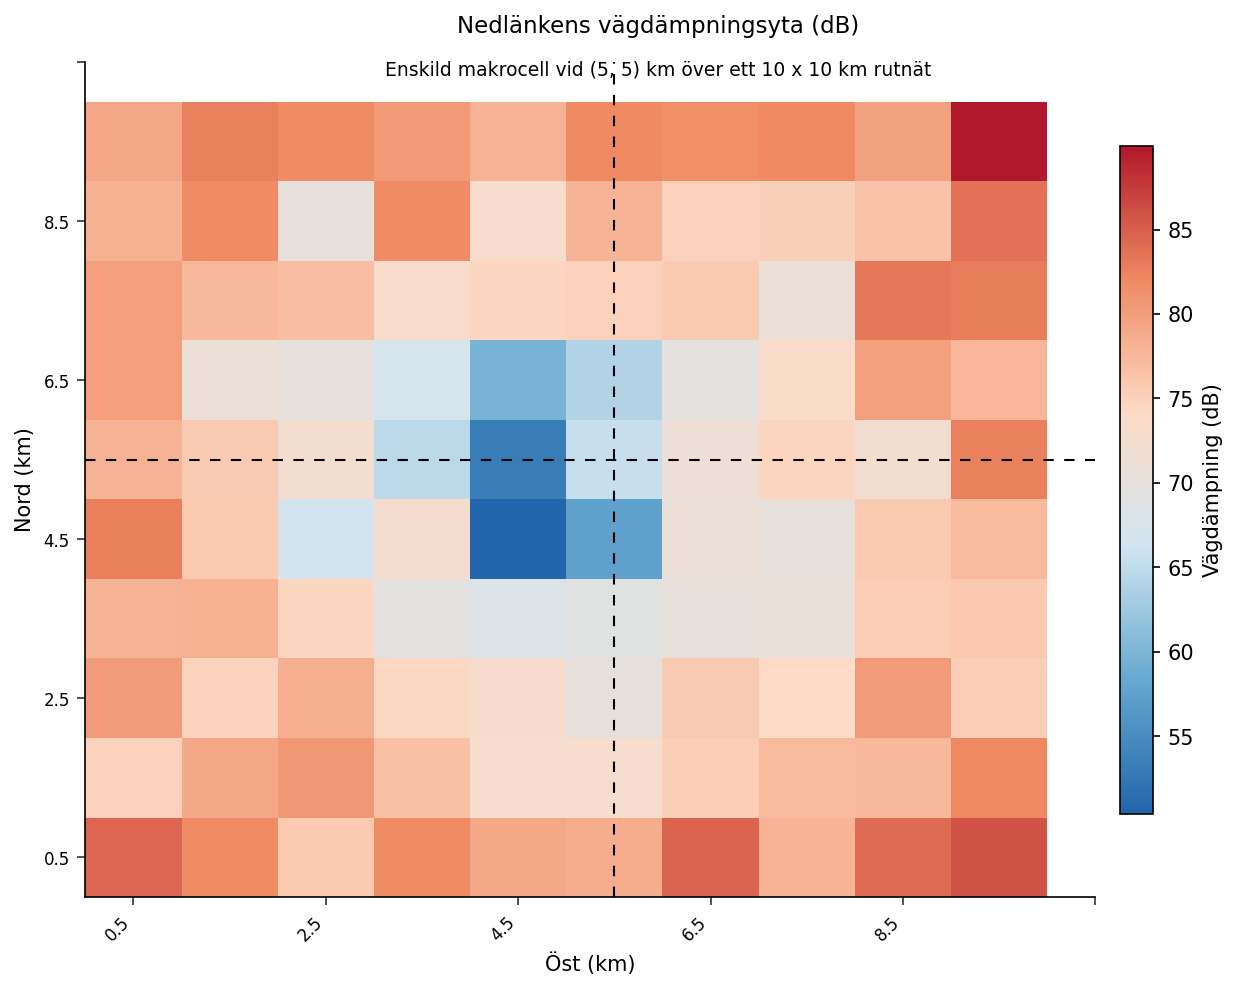

In [4]:
ODS GRAPHICS ON;
TITEL "Nedlänkens vägdämpningsyta (dB)";
title2 "Enskild makrocell vid (5, 5) km över ett 10 x 10 km rutnät";

PROCEDUR SGPLOT data=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITEL="Vägdämpning (dB)";
   refline 5 / axis=x lineattrs=(color=black pattern=shortdash);
   refline 5 / axis=y lineattrs=(color=black pattern=shortdash);
   xaxis values=(0 2 4 6 8 10) ETIKETT="Öst (km)";
   yaxis values=(0 2 4 6 8 10) ETIKETT="Nord (km)";
KÖR;

TITEL; title2;

## Steg 5 — Fördelning per täckningsklass

En briefingbild vill också ha huvudfördelningen: hur stor andel av fotavtrycket är Stark, Godkänd eller Svag. Ett `VBAR` över `zone`-klassificeringen ger den överblicken och kompletterar konturytan ovan.

                                             Uppdelning per täckningsklass                                              




NOTE: Option TITLE changed to Uppdelning per täckningsklass.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


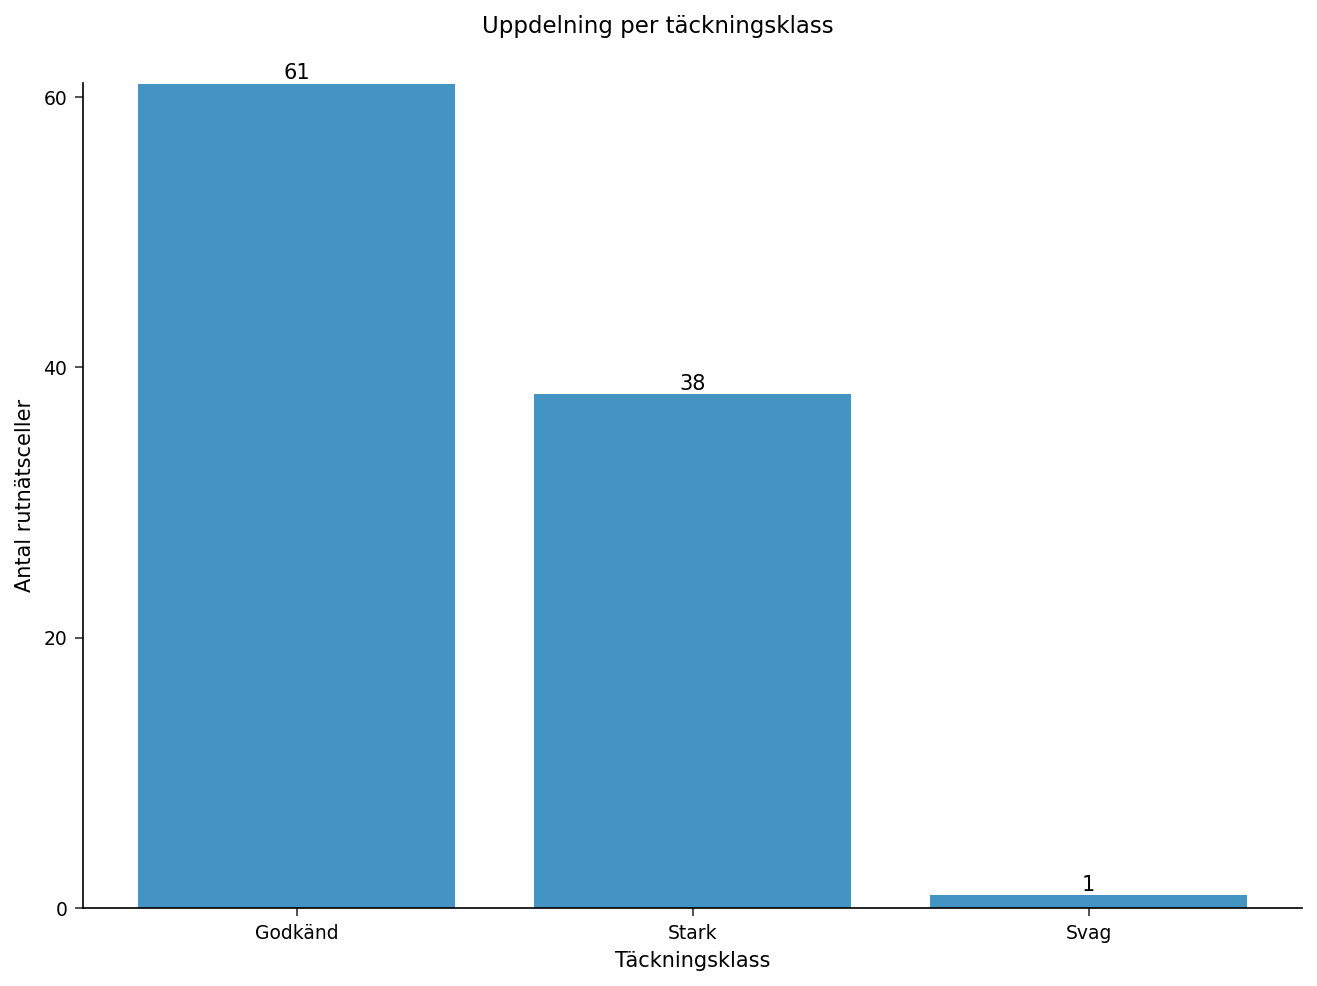

In [5]:
TITEL "Uppdelning per täckningsklass";

PROCEDUR SGPLOT data=pathloss_grid;
   vbar zone / datalabel fillattrs=(color=CX4393C3) nooutline;
   xaxis ETIKETT="Täckningsklass";
   yaxis ETIKETT="Antal rutnätsceller" values=(0 20 40 60);
KÖR;

TITEL;

## Tolkning av resultaten

Konturytan bekräftar den förväntade utbredningsfysiken. Vägdämpningen är lägst i en tät **blå bassäng kring masten vid (5, 5) km** — Stark-zonen där den mottagna signalen är bäst — och ökar med den logaritmiska avståndsökningen mot hörnen. Eftersom vi injicerade log-normal skuggfädning är banden inte koncentriska cirklar; de ojämna röda rutorna längs gränsen är den skuggfädade kanten.

Den handlingsbara slutsatsen är den **enskilda Svag-rutan vid (9,5, 9,5) km (89,97 dB)**, hörnet diagonalt motsatt masten och den enda punkten som korsar designtröskeln på 88 dB. Med **61 av 100 rutor Godkänd och bara 1 Svag** täcker denna makrocell sitt serviceområde väl; det ensamma hålet skulle motivera en **small-cell-komplettering eller en sektoromriktning mot nordöstra hörnet** endast om det överlappade en känd efterfrågehotspot. Konturytan är den briefingklara sammanfattningen; stapeldiagrammet för täckningsklass ger den entalssiffra en kapacitetsplanerare rapporterar uppåt.